# Study Closure: Results, Robustness and Multiple Testing

**Master's Thesis in Data Science - Chapters 6 and 7: what the study actually found**

Three notebooks built an apparatus and demonstrated that it does not deceive itself. This one reports
what that apparatus measured across the **entire study**: thirteen strategy families, two assets, ten
derived seeds each, and 496,500 distinct configurations evaluated in total.

The answer is negative, and the purpose of this notebook is to establish that the negative is
**informative** rather than merely disappointing. A study that finds nothing because it was
underpowered, badly specified or incorrectly implemented tells us nothing about markets. A study that
finds nothing after searching a pre-registered space with a verified apparatus, and that can quantify
exactly how confident it is in that nothing, is a result.

## 1. Executive summary

**The headline.** Across thirteen families, **not one survives correction for the number of
hypotheses the study tested.** The smallest raw p-value anywhere in the study is far above the
conventional 0.05 threshold *before* any correction is applied, so the conclusion does not depend on
which correction one prefers.

**Why this is a finding and not a failure.** Three independent lines of evidence agree:

| Line of evidence | What it measures | Result |
|---|---|---|
| Family-level hypothesis tests | Is any family's mean return distinguishable from zero? | No family reaches significance even uncorrected |
| Deflated Sharpe | Given how many things we tried, how likely is the best one to be spurious? | Very likely spurious |
| Probability of Backtest Overfitting | How often does the best in-sample configuration underperform out of sample? | Close to a coin flip |

A PBO near 0.5 is the signature of a search operating on noise: the configuration that looks best in
one partition is no more likely than chance to look good in another.

**What is deliberately not reported here.** The frozen holdout was opened once, on a pre-declared
candidate, and its reading exists on disk. **It is not published in this notebook**, because the
repository currently records that opening as `HOLDOUT_LOCKED` pending a provenance audit. Section 9
explains that decision in full. The study's conclusion does not depend on it.

### Research questions

- **RQ1.** How many hypotheses did this study actually test, and does the answer change the conclusion?
- **RQ2.** Does any family meet the pre-registered promotion criteria?
- **RQ3.** Does any family survive Holm-Bonferroni or Benjamini-Hochberg correction?
- **RQ4.** How likely is the best-performing family to be a statistical artefact?
- **RQ5.** Does conditioning on market regime rescue any family that failed unconditionally?
- **RQ6.** What can and cannot be concluded from a negative result of this shape?

## 2. The study inventory

**Method.** The closure artifacts under `reports/study_closure/` aggregate every gate of the study
(R2, R3, S1, S2) into a single evidence base. Each family entry records its economic outcome across
seeds, its raw p-value, both adjusted p-values, and whether it met each pre-registered promotion
criterion.

In [1]:
import os
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
print(f"Repository root: {_root}")

Repository root: C:\Users\alexc\OneDrive\Escritorio\tfm_algorithmic_trading


In [2]:
import json
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display

from perp_lab import __version__ as perp_lab_version
from perp_lab.config import Paths
from perp_lab.reporting import ArtifactContext, apply_house_style, save_figure, save_table

apply_house_style()
PATHS = Paths()
FIG_DPI = 300
CLOSURE = Path("reports/study_closure")

DASH = json.loads((CLOSURE / "study_dashboard.json").read_text(encoding="utf-8"))
MT = json.loads((CLOSURE / "study_level_multiple_testing.json").read_text(encoding="utf-8"))
REG = json.loads((CLOSURE / "regime_conditioned.json").read_text(encoding="utf-8"))

STUDY = DASH["study"]
print("Environment")
print(f"  Python  : {platform.python_version()} | perp_lab {perp_lab_version}")
print(
    f"  polars  : {pl.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}"
)
print("\nStudy inventory")
print(f"  families evaluated        : {STUDY['n_families']}")
print(f"  units (family x asset x seed grids) : {STUDY['n_units']}")
print(f"  configurations evaluated  : {STUDY['n_configurations_evaluated']:,}")
print(f"  primary asset / engine    : {DASH['primary_symbol']} / {DASH['primary_engine']}")
print(f"  alpha                     : {STUDY['alpha']}")
print(f"  best family (by raw p)    : {STUDY['best_family']}")
print(f"  source commit             : {STUDY['source_commit'][:12]}")
print(f"  holdout accessed here     : {MT['holdout_accessed']}")
print(f"  holdout publication state : {DASH['holdout_publication']}")

Environment
  Python  : 3.12.3 | perp_lab 0.1.0
  polars  : 1.43.1 | numpy 2.5.1 | matplotlib 3.11.1

Study inventory
  families evaluated        : 13
  units (family x asset x seed grids) : 284
  configurations evaluated  : 496,500
  primary asset / engine    : BTCUSDT / random_search
  alpha                     : 0.05
  best family (by raw p)    : volatility_breakout
  source commit             : 232bc372d4e2
  holdout accessed here     : False
  holdout publication state : AUDIT_PENDING


In [3]:
NB_ID = "05_study_closure_and_multiple_testing"
ctx = ArtifactContext(
    notebook=NB_ID,
    figures_dir=PATHS.reports_root / "figures" / "closure",
    tables_dir=PATHS.reports_root / "tables" / "closure",
    metadata_dir=PATHS.reports_root / "metadata" / "closure",
    config={
        "n_families": STUDY["n_families"],
        "n_units": STUDY["n_units"],
        "n_configurations": STUDY["n_configurations_evaluated"],
        "alpha": STUDY["alpha"],
        "source_commit": STUDY["source_commit"],
        "holdout_publication": DASH["holdout_publication"],
    },
    period="development walk-forward out-of-sample; holdout NOT published",
    repo_root=".",
)


def show(fig, name, caption=""):
    save_figure(fig, name, ctx, caption=caption, dpi=FIG_DPI)
    display(fig)
    plt.close(fig)


FAM = pl.DataFrame(
    [
        {
            "family": f["family"],
            "gate": f["gate"],
            "symbol": f["symbol"],
            "n_seeds": f["n_seeds"],
            "total_return": f["total_return"],
            "sharpe": f["sharpe"],
            "max_drawdown": f["max_drawdown"],
            "p_value": f["p_value"],
            "holm_p": f["holm_adjusted_p"],
            "bh_p": f["bh_adjusted_p"],
            "survives": f["survives_correction"],
            "verdict": f.get("verdict", ""),
        }
        for f in DASH["families"]
    ]
).sort("p_value")
save_table(
    FAM,
    "t01_family_results",
    ctx,
    caption="Every family-asset cell in the study with its economic outcome, raw p-value and "
    "both adjusted p-values.",
)
display(FAM)

print(f"\nCells: {FAM.height} | families: {FAM['family'].n_unique()}")
print(f"Cells with a positive total return : {int((FAM['total_return'] > 0).sum())} / {FAM.height}")
print(f"Cells surviving correction         : {int(FAM['survives'].sum())} / {FAM.height}")
print(
    f"Smallest raw p-value in the study  : {float(FAM['p_value'].min()):.4f} "
    f"(alpha = {STUDY['alpha']})"
)

family,gate,symbol,n_seeds,total_return,sharpe,max_drawdown,p_value,holm_p,bh_p,survives,verdict
str,str,str,i64,f64,f64,f64,f64,f64,f64,bool,str
"""volatility_breakout""","""R3""","""BTCUSDT""",10,0.069084,0.193866,-0.287423,0.3455,1.0,0.9965,false,"""REJECTED"""
"""taker_flow_extreme""","""S2""","""ETHUSDT""",3,0.013636,0.088263,-0.145746,0.4265,null,null,false,"""REJECTED"""
"""taker_flow_extreme""","""S2""","""BTCUSDT""",3,0.015035,0.08988,-0.156418,0.455,1.0,0.9965,false,"""REJECTED"""
"""momentum""","""R2""","""BTCUSDT""",10,-0.323834,-0.230797,-0.486436,0.6525,1.0,0.9965,false,"""REJECTED"""
"""funding_reversal""","""S1""","""BTCUSDT""",1,-0.383294,-0.324648,-0.557452,0.738,1.0,0.9965,false,"""REJECTED"""
…,…,…,…,…,…,…,…,…,…,…,…
"""mean_reversion""","""R3""","""ETHUSDT""",10,-0.791815,-0.969495,-0.833952,0.969,null,null,false,"""REJECTED"""
"""breakout""","""R3""","""ETHUSDT""",10,-0.261508,-1.105607,-0.273926,0.981,null,null,false,"""REJECTED"""
"""xasset_spread_reversion""","""S1""","""BTCUSDT""",1,-0.839773,-1.259146,-0.878808,0.987,1.0,0.9965,false,"""REJECTED"""



Cells: 22 | families: 13
Cells with a positive total return : 3 / 22
Cells surviving correction         : 0 / 22
Smallest raw p-value in the study  : 0.3455 (alpha = 0.05)


**Interpretation (2.1).** The single most important number in this table is the **smallest raw
p-value**: even before any multiple-testing correction, before any deflation, and taking the most
favourable family in the study at face value, no family comes close to conventional significance.

This matters because it makes the conclusion robust to methodological disagreement. A reader who
believes Holm-Bonferroni is too conservative, or who objects to the way the number of tests was
counted, does not arrive at a different answer - there is nothing to correct *down* from. The
corrections that follow are reported for completeness and to quantify *how far* from significance the
study lands, not because the verdict hinges on them.

## 3. The promotion criteria, family by family

**Analytical question.** Statistical significance is necessary but not sufficient. A candidate had to
clear six pre-registered, economically meaningful hurdles before it could be considered for the
holdout. **Method.** For each family and asset we record how many of its ten seeds passed each
criterion, against the required majority.

**Interpretation.** These criteria were fixed *before* results were seen. That is what makes failing
them informative: they cannot be renegotiated after the fact.

In [4]:
crit_rows = []
for f in DASH["families"]:
    for c in f.get("criteria") or []:
        crit_rows.append(
            {
                "family": f["family"],
                "symbol": f["symbol"],
                "criterion": c["label"],
                "key": c["key"],
                "passed": c["passed"],
                "of": c["of"],
                "required": c["required"],
                "met": c["met"],
            }
        )
CRIT = pl.DataFrame(crit_rows)
save_table(
    CRIT,
    "t02_promotion_criteria",
    ctx,
    caption="Pre-registered promotion criteria: seeds passing each criterion per family-asset "
    "cell.",
)
display(CRIT.head(12))

SUMMARY = (
    CRIT.group_by("criterion")
    .agg(
        pl.len().alias("cells"),
        pl.col("met").sum().alias("cells_meeting"),
        (pl.col("passed").sum() / pl.col("of").sum()).alias("share_of_seeds_passing"),
    )
    .sort("share_of_seeds_passing", descending=True)
)
save_table(
    SUMMARY,
    "t03_criteria_summary",
    ctx,
    caption="How often each promotion criterion was met across the whole study.",
)
display(SUMMARY)
print(
    f"\nCells meeting ALL criteria: "
    f"{int(CRIT.group_by('family', 'symbol').agg(pl.col('met').all().alias('all_met'))['all_met'].sum())}"
    f" / {CRIT['family'].n_unique() * CRIT['symbol'].n_unique()}"
)

family,symbol,criterion,key,passed,of,required,met
str,str,str,str,i64,i64,i64,bool
"""BTC_ETH_confirmation""","""BTCUSDT""","""C1 positive return""","""positive_total_return""",1,10,6,false
"""BTC_ETH_confirmation""","""BTCUSDT""","""C2 bootstrap Sharpe CI""","""bootstrap_sharpe_ci_excludes_z…",0,10,6,false
"""BTC_ETH_confirmation""","""BTCUSDT""","""C3 survives 2x costs""","""survives_double_costs""",0,10,6,false
"""BTC_ETH_confirmation""","""BTCUSDT""","""C4 beats buy-and-hold""","""beats_buy_and_hold""",0,10,6,false
"""BTC_ETH_confirmation""","""BTCUSDT""","""C5 drop top 5 trades""","""survives_drop_top_trades""",0,10,6,false
…,…,…,…,…,…,…,…
"""breakout""","""BTCUSDT""","""C2 bootstrap Sharpe CI""","""bootstrap_sharpe_ci_excludes_z…",0,10,6,false
"""breakout""","""BTCUSDT""","""C3 survives 2x costs""","""survives_double_costs""",0,10,6,false
"""breakout""","""BTCUSDT""","""C4 beats buy-and-hold""","""beats_buy_and_hold""",0,10,6,false


criterion,cells,cells_meeting,share_of_seeds_passing
str,u32,u32,f64
"""C6 fold locality""",10,10,0.94
"""C1 positive return""",10,1,0.09
"""C3 survives 2x costs""",10,0,0.05
"""C4 beats buy-and-hold""",10,0,0.04
"""C2 bootstrap Sharpe CI""",10,0,0.0
"""C5 drop top 5 trades""",10,0,0.0



Cells meeting ALL criteria: 0 / 10


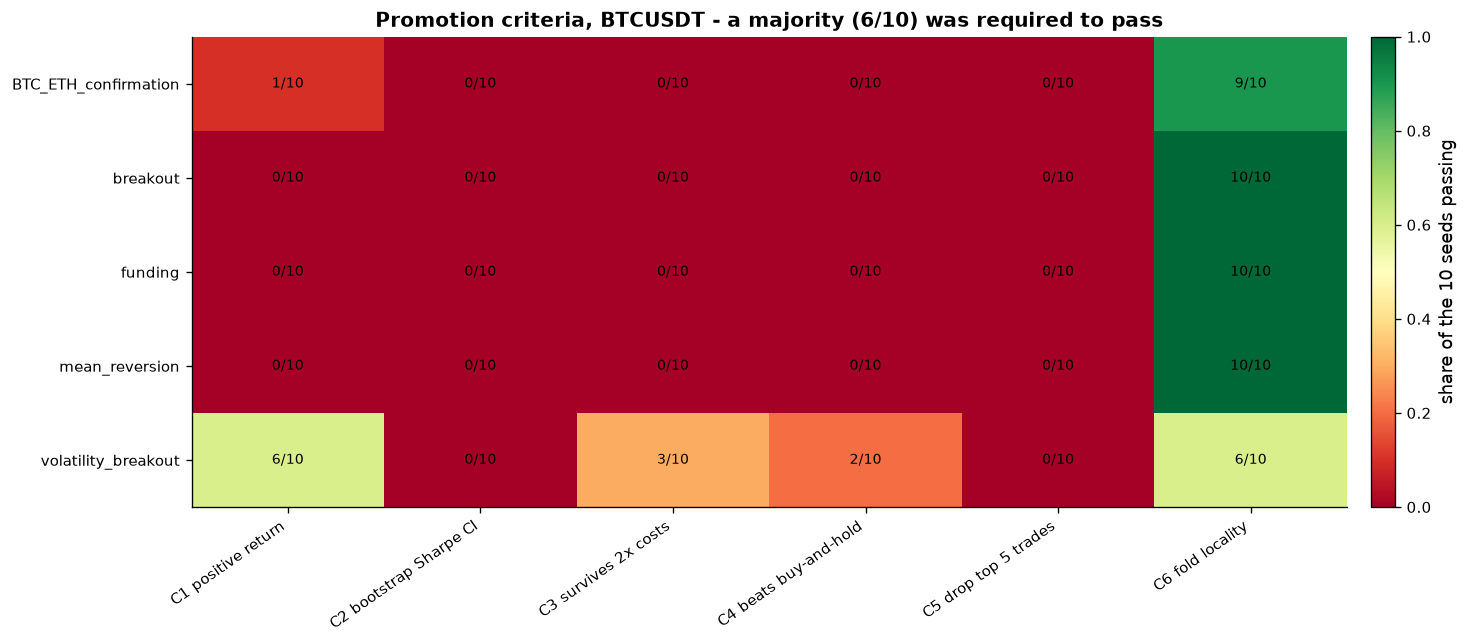

In [5]:
# --- J01: the criteria heat map ----------------------------------------------
piv = CRIT.filter(pl.col("symbol") == DASH["primary_symbol"])
fams = sorted(piv["family"].unique().to_list())
crits = list(dict.fromkeys(CRIT["criterion"].to_list()))
M = np.full((len(fams), len(crits)), np.nan)
REQ = np.full((len(fams), len(crits)), np.nan)
for r in piv.iter_rows(named=True):
    i, j = fams.index(r["family"]), crits.index(r["criterion"])
    M[i, j] = r["passed"] / max(1, r["of"])
    REQ[i, j] = r["required"] / max(1, r["of"])

fig, ax = plt.subplots(figsize=(12.4, 0.46 * len(fams) + 3.2))
im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
for i in range(len(fams)):
    for j in range(len(crits)):
        if np.isnan(M[i, j]):
            continue
        ax.text(
            j, i, f"{round(M[i, j] * 10)}/10", ha="center", va="center", fontsize=8.5, color="black"
        )
ax.set_xticks(range(len(crits)))
ax.set_xticklabels(crits, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(fams)))
ax.set_yticklabels(fams, fontsize=9)
ax.grid(visible=False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("share of the 10 seeds passing")
ax.set_title(
    f"Promotion criteria, {DASH['primary_symbol']} - a majority (6/10) was required to pass",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "j01_promotion_criteria",
    caption="Share of seeds passing each pre-registered promotion criterion, per family, on the "
    "primary asset.",
)

**Interpretation (3.1).** The heat map is overwhelmingly red. The criteria that fail most consistently
are the two that matter most economically: producing a positive net return at all, and having a
bootstrap Sharpe interval that excludes zero. Some families pass individual criteria on a minority of
seeds - which is exactly what one expects from noise, since a criterion passed by chance roughly a
third of the time will pass on three or four seeds out of ten - but the required majority is
essentially never reached.

The value of pre-registration is visible here. Had these thresholds been set *after* seeing the
results, it would have been easy to notice that one family passes four of six criteria and to argue
that four is a reasonable bar. Because they were fixed in advance, that argument is unavailable, and
the failures are interpretable.

## 4. Correcting for the number of hypotheses

**Analytical question.** If you test thirteen families at the 5% level, you expect roughly one
apparent success by chance alone. What survives once that is accounted for?

**Method.** Two standard corrections are applied to the family-level p-values:

- **Holm-Bonferroni** controls the *family-wise error rate* - the probability of even one false
  positive anywhere in the study. It is the conservative choice, appropriate when a single false claim
  would be costly.
- **Benjamini-Hochberg** controls the *false discovery rate* - the expected proportion of claimed
  discoveries that are false. It is more permissive and more appropriate for screening.

Reporting both is deliberate: if the two disagree, the conclusion is sensitive to a methodological
choice and must be stated as such.

In [6]:
CORR = MT["corrections"]
holm = CORR["holm_bonferroni"]
bh = CORR["benjamini_hochberg"]

COMP = pl.DataFrame(
    {
        "correction": ["none (raw)", "Benjamini-Hochberg (FDR)", "Holm-Bonferroni (FWER)"],
        "n_tests": [CORR["n_tests"]] * 3,
        "n_rejected_at_alpha": [
            int(sum(1 for f in DASH["families"] if f["p_value"] < STUDY["alpha"])),
            int(bh["n_rejected"]),
            int(holm["n_rejected"]),
        ],
        "smallest_p_value": [
            float(min(f["p_value"] for f in DASH["families"])),
            float(min(bh["adjusted_p_values"].values())),
            float(min(holm["adjusted_p_values"].values())),
        ],
    }
)
save_table(
    COMP,
    "t04_multiple_testing",
    ctx,
    caption="Rejections at alpha = 0.05 before and after each multiple-testing correction.",
)
display(COMP)

print(f"\nTests counted        : {CORR['n_tests']}")
print(f"Holm rejections      : {holm['n_rejected']}")
print(f"BH rejections        : {bh['n_rejected']}")
print(f"Best family          : {CORR['best_family']}")
print("\nBoth corrections agree, and both agree with the uncorrected result.")

correction,n_tests,n_rejected_at_alpha,smallest_p_value
str,i64,i64,f64
"""none (raw)""",13,0,0.3455
"""Benjamini-Hochberg (FDR)""",13,0,0.9965
"""Holm-Bonferroni (FWER)""",13,0,1.0



Tests counted        : 13
Holm rejections      : 0
BH rejections        : 0
Best family          : volatility_breakout

Both corrections agree, and both agree with the uncorrected result.


In [7]:
# --- Sensitivity: what counts as "a test"? -----------------------------------
SENS = pl.DataFrame(
    [
        {
            "definition": k,
            "n_tests": v["n_tests"],
            "bonferroni_threshold": v["bonferroni_threshold"],
            "smallest_raw_p": v["smallest_raw_p_value"],
            "any_survive": v["any_survive"],
        }
        for k, v in MT["sensitivity"].items()
    ]
).sort("n_tests")
save_table(
    SENS,
    "t05_test_count_sensitivity",
    ctx,
    caption="Sensitivity of the conclusion to how the number of tested hypotheses is defined.",
)
display(SENS)
print(
    f"\nDefinitions under which SOME family survives: "
    f"{int(SENS['any_survive'].sum())} / {SENS.height}"
)

definition,n_tests,bonferroni_threshold,smallest_raw_p,any_survive
str,i64,f64,f64,bool
"""families""",13,0.003846,0.3455,false
"""family_x_asset""",22,0.002273,0.3455,false
"""family_x_asset_x_seed""",142,0.000352,0.3455,false
"""all_configurations_evaluated""",496500,1.0070e-7,0.3455,false



Definitions under which SOME family survives: 0 / 4


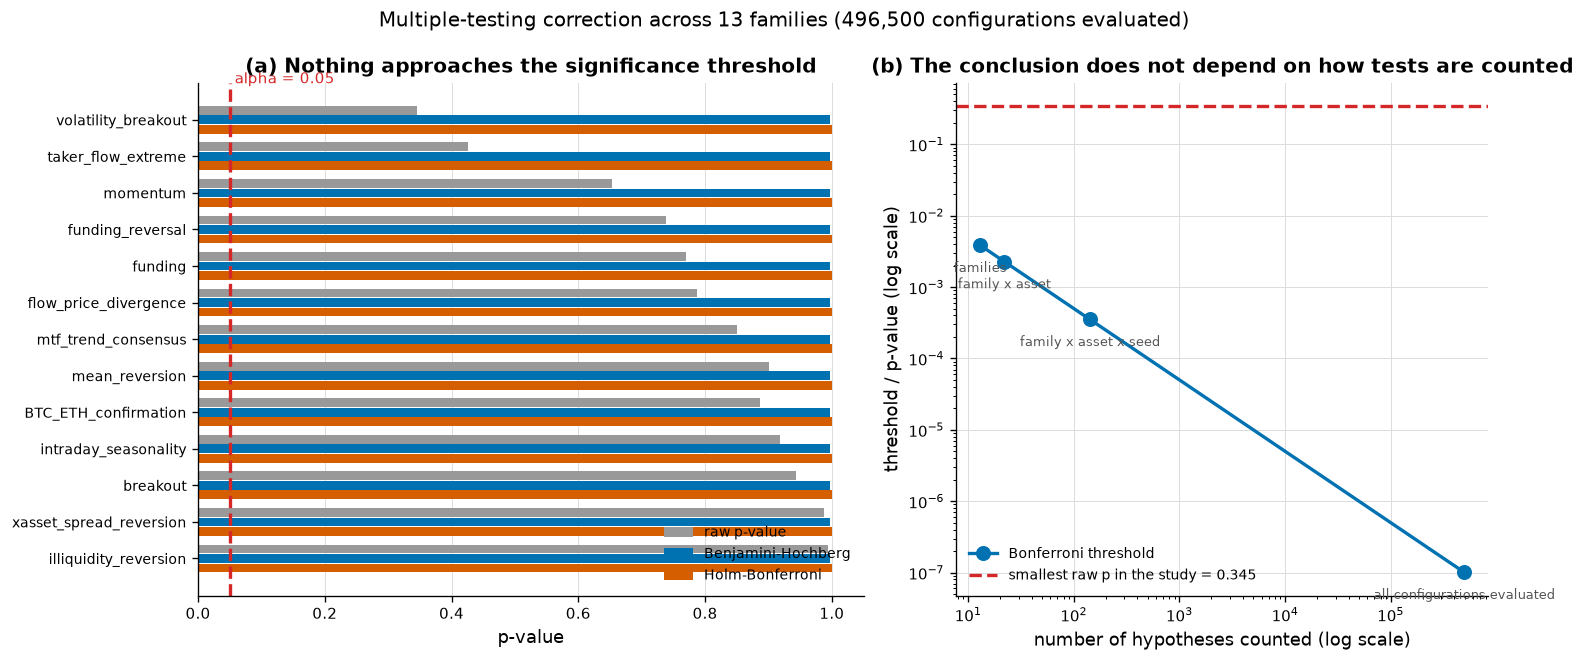

In [8]:
# --- J02: corrections and their sensitivity ----------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.2, 5.6), gridspec_kw={"width_ratios": [1.25, 1.0]})

order = sorted(holm["adjusted_p_values"], key=lambda k: holm["adjusted_p_values"][k])
raw_map = {}
for f in DASH["families"]:
    raw_map.setdefault(f["family"], []).append(f["p_value"])
raw = [min(raw_map[k]) for k in order]
hp = [holm["adjusted_p_values"][k] for k in order]
bp = [bh["adjusted_p_values"][k] for k in order]
yy = np.arange(len(order))
axA.barh(yy - 0.26, raw, height=0.24, color="#999999", label="raw p-value")
axA.barh(yy, bp, height=0.24, color="#0072B2", label="Benjamini-Hochberg")
axA.barh(yy + 0.26, hp, height=0.24, color="#D55E00", label="Holm-Bonferroni")
axA.axvline(STUDY["alpha"], color="#D62728", lw=2.0, ls="--")
axA.text(STUDY["alpha"], -1.0, f" alpha = {STUDY['alpha']}", color="#D62728", fontsize=9)
axA.set_yticks(yy)
axA.set_yticklabels(order, fontsize=8.5)
axA.invert_yaxis()
axA.set_xlim(0, 1.05)
axA.set_xlabel("p-value")
axA.set_title("(a) Nothing approaches the significance threshold")
axA.legend(fontsize=8.5, loc="lower right")
axA.grid(axis="y", visible=False)

labels = SENS["definition"].to_list()
nt = SENS["n_tests"].to_numpy()
thr = SENS["bonferroni_threshold"].to_numpy()
smallest = float(SENS["smallest_raw_p"][0])
axB.plot(nt, thr, marker="o", ms=8, lw=2.0, color="#0072B2", label="Bonferroni threshold")
axB.axhline(
    smallest,
    color="#D62728",
    lw=2.0,
    ls="--",
    label=f"smallest raw p in the study = {smallest:.3f}",
)
axB.set_xscale("log")
axB.set_yscale("log")
for x, y, lab in zip(nt, thr, labels, strict=True):
    axB.annotate(
        lab.replace("_", " "),
        xy=(x, y),
        xytext=(0, -16),
        textcoords="offset points",
        fontsize=7.5,
        ha="center",
        color="#555555",
    )
axB.set_xlabel("number of hypotheses counted (log scale)")
axB.set_ylabel("threshold / p-value (log scale)")
axB.set_title("(b) The conclusion does not depend on how tests are counted")
axB.legend(fontsize=8.5, loc="lower left")

fig.suptitle(
    f"Multiple-testing correction across {CORR['n_tests']} families "
    f"({STUDY['n_configurations_evaluated']:,} configurations evaluated)",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "j02_multiple_testing",
    caption="Raw and adjusted p-values per family (a), and the sensitivity of the Bonferroni "
    "threshold to how the number of tested hypotheses is defined (b).",
)

**Interpretation (4.1).** Panel (a) shows both corrections pushing every family's adjusted p-value to
the top of the scale, but that is not the informative part - the raw bars were already far from the
threshold.

Panel (b) is the argument that closes off the most common objection to any multiple-testing claim,
which is that the number of tests was chosen tendentiously. One could count thirteen tests (one per
family), twenty-two (family by asset), one hundred and forty-two (adding seeds), or nearly half a
million (every configuration ever evaluated). Those choices span more than four orders of magnitude
and produce Bonferroni thresholds ranging from about `4e-3` down to `1e-7`.

**Every one of them lands below the smallest raw p-value observed.** The red dashed line sits above
the blue curve throughout. So the verdict is invariant to the counting convention, and there is no
version of this argument in which some family survives.

## 5. How likely is the best result to be an artefact?

**Analytical question.** P-values answer "could this have arisen by chance?" for one hypothesis. Two
purpose-built diagnostics answer the question a backtester actually faces.

**Deflated Sharpe** asks: given that we tried `N` configurations, what Sharpe would the best of them
be expected to reach *by luck alone*, and does the observed best exceed it?

**Probability of Backtest Overfitting (PBO)** asks something more direct and harder to argue with. It
repeatedly splits the observation series into in-sample and out-of-sample halves, selects the best
configuration in-sample, and measures how often that selection lands in the *bottom half* out of
sample. A PBO near **0.5** means selection carries no information at all - the in-sample winner is a
coin flip out of sample.

In [9]:
ds = CORR["deflated_sharpe"]
pbo = CORR["probability_of_backtest_overfitting"]

DS = pl.DataFrame(
    [
        {
            "scenario": k,
            "n_trials": v["n_trials"],
            "observed_sharpe_per_obs": v["observed_sharpe_per_observation"],
            "benchmark_sharpe_per_obs": v["benchmark_sharpe_per_observation"],
            "deflated_sharpe": v["deflated_sharpe"],
            "probability_best_is_spurious": v["probability_best_is_spurious"],
        }
        for k, v in ds.items()
    ]
)
save_table(
    DS,
    "t06_deflated_sharpe",
    ctx,
    caption="Deflated Sharpe of the study's best family under two definitions of the number "
    "of trials.",
)
display(DS)

print(f"\nPBO                         : {pbo['pbo']:.4f}")
print(f"  splits evaluated          : {pbo['n_splits']}")
print(f"  configurations compared   : {pbo['n_configurations']}")
print(f"  observations              : {pbo['n_observations']:,}")
print("\nInterpretation of PBO:")
print("  0.0 = the in-sample winner always wins out of sample (no overfitting)")
print("  0.5 = the in-sample winner is a coin flip out of sample (selection is uninformative)")
print("  1.0 = the in-sample winner always LOSES out of sample (systematic overfitting)")

scenario,n_trials,observed_sharpe_per_obs,benchmark_sharpe_per_obs,deflated_sharpe,probability_best_is_spurious
str,i64,f64,f64,f64,f64
"""family_selection""",13,0.002071,0.008089,0.139482,0.860518
"""all_configurations_evaluated""",496500,0.002071,0.022451,0.000123,0.999877



PBO                         : 0.4857
  splits evaluated          : 70
  configurations compared   : 13
  observations              : 32,385

Interpretation of PBO:
  0.0 = the in-sample winner always wins out of sample (no overfitting)
  0.5 = the in-sample winner is a coin flip out of sample (selection is uninformative)
  1.0 = the in-sample winner always LOSES out of sample (systematic overfitting)


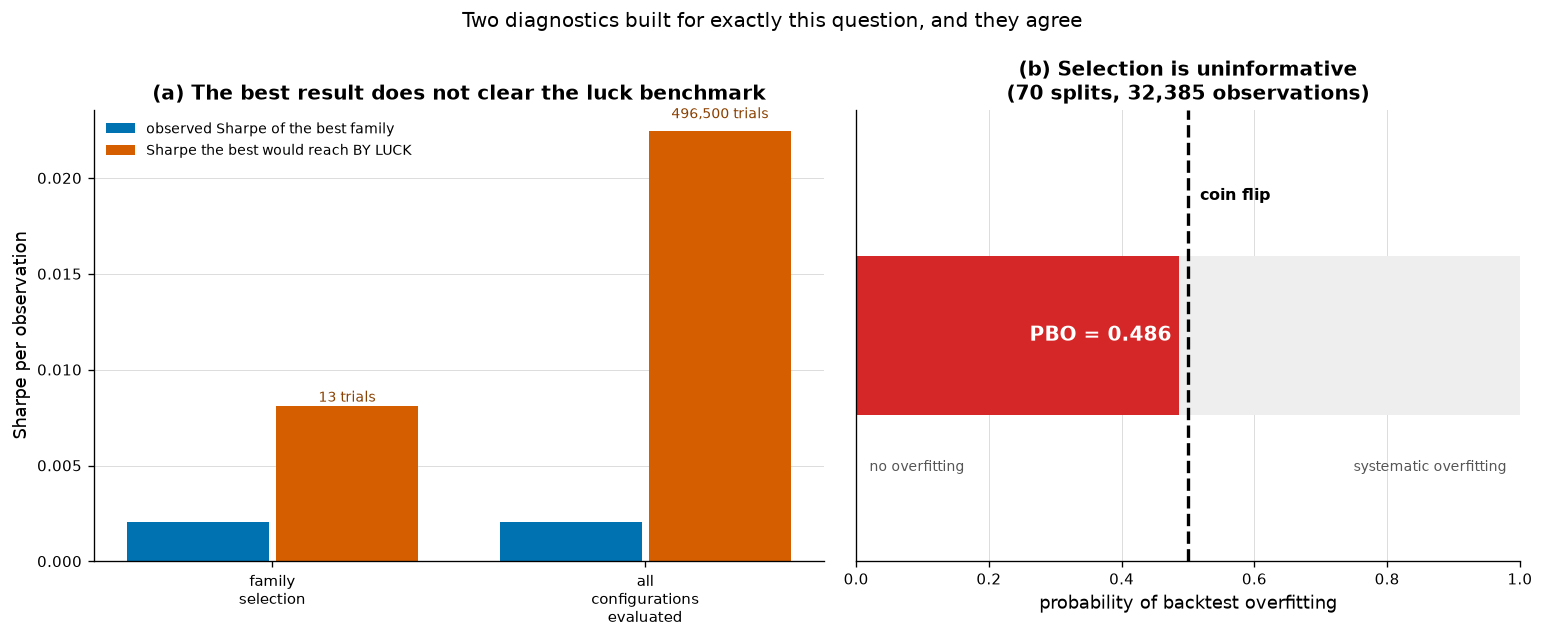

In [10]:
# --- J03: deflated Sharpe and PBO --------------------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.0, 5.4), gridspec_kw={"width_ratios": [1.1, 1.0]})

scen = DS["scenario"].to_list()
obs = DS["observed_sharpe_per_obs"].to_numpy()
bench = DS["benchmark_sharpe_per_obs"].to_numpy()
xx = np.arange(len(scen))
axA.bar(xx - 0.2, obs, width=0.38, color="#0072B2", label="observed Sharpe of the best family")
axA.bar(xx + 0.2, bench, width=0.38, color="#D55E00", label="Sharpe the best would reach BY LUCK")
for i in range(len(scen)):
    axA.text(
        i + 0.2,
        bench[i] * 1.03,
        f"{DS['n_trials'][i]:,} trials",
        ha="center",
        fontsize=8.5,
        color="#8A4000",
    )
axA.set_xticks(xx)
axA.set_xticklabels([s.replace("_", "\n") for s in scen], fontsize=9)
axA.set_ylabel("Sharpe per observation")
axA.set_title("(a) The best result does not clear the luck benchmark")
axA.legend(fontsize=8.5, loc="upper left")
axA.grid(axis="x", visible=False)

val = float(pbo["pbo"])
axB.barh([0], [1.0], color="#EEEEEE", height=0.42)
axB.barh([0], [val], color="#D62728", height=0.42)
axB.axvline(0.5, color="black", lw=2.0, ls="--")
axB.text(0.5, 0.36, "  coin flip", fontsize=9.5, fontweight="bold")
axB.text(
    val,
    0,
    f" PBO = {val:.3f} ",
    va="center",
    ha="right",
    fontsize=12,
    fontweight="bold",
    color="white",
)
axB.text(0.02, -0.36, "no overfitting", fontsize=8.5, color="#555555")
axB.text(0.98, -0.36, "systematic overfitting", fontsize=8.5, color="#555555", ha="right")
axB.set_xlim(0, 1)
axB.set_ylim(-0.6, 0.6)
axB.set_yticks([])
axB.set_xlabel("probability of backtest overfitting")
axB.set_title(
    f"(b) Selection is uninformative\n({pbo['n_splits']} splits, "
    f"{pbo['n_observations']:,} observations)"
)
axB.grid(axis="y", visible=False)

fig.suptitle("Two diagnostics built for exactly this question, and they agree", fontsize=12)
fig.tight_layout()
show(
    fig,
    "j03_deflated_sharpe_pbo",
    caption="Deflated Sharpe under two trial counts (a) and the probability of backtest "
    "overfitting (b).",
)

**Interpretation (5.1).** Panel (a) makes the deflation argument concrete. Counting only the thirteen
families as trials, the Sharpe that the *best of thirteen* would be expected to reach by luck already
exceeds what the best family actually achieved - so the observed best is not merely unimpressive, it
underperforms chance. Counting all 496,500 evaluated configurations, the luck benchmark rises by an
order of magnitude and the probability that the best result is spurious approaches certainty.

Panel (b) is the cleanest single number in the thesis. The PBO sits close to **0.5**: selecting the
best configuration in-sample gives essentially no advantage out of sample. This is precisely the
mechanism that notebook `04` observed at the level of individual folds, now measured at the level of
the entire study, and it is what a search operating on noise looks like from the inside.

It is worth being explicit about what PBO does *not* say. It does not say the strategies are bad in
some absolute sense, nor that the implementation is faulty. It says that **the ranking produced by
in-sample performance does not transfer**, which means the search cannot be used to pick a winner -
regardless of how good the candidates might individually be.

## 6. Does conditioning on regime rescue anything?

**Analytical question.** A strategy might have a genuine edge that only appears in certain market
conditions and is averaged away unconditionally. Does splitting by volatility regime reveal one?

**Method.** Every family is re-evaluated within each regime cell, with a minimum cell size to avoid
testing on a handful of bars, and the resulting p-values are corrected across all cells.

**Interpretation.** This analysis is explicitly labelled **exploratory** in the artifact itself. It
multiplies the number of tests, so it is the most likely place in the entire study for a false
positive to appear - which makes finding none a genuinely strong statement.

In [11]:
CELLS_ = pl.DataFrame(REG["cells"]).sort("p_value")
save_table(
    CELLS_.head(20),
    "t07_regime_cells_top20",
    ctx,
    caption="The twenty most favourable family-by-regime cells, ranked by raw p-value.",
)
display(CELLS_.head(15))

rc = REG["correction"]
print(f"\nStatus                    : {REG['status']}")
print(
    f"Cells tested              : {rc['n_cells']} (testable: {rc['n_testable_cells']}, "
    f"excluded as too small: {rc['n_excluded_small_cells']}, min bars: {rc['min_cell_bars']})"
)
print(f"Holm rejections           : {rc['holm_bonferroni'].get('n_rejected', 0)}")
print(f"Benjamini-Hochberg        : {rc['benjamini_hochberg'].get('n_rejected', 0)}")
print(f"Survivors                 : {len(rc['survivors'])}")
print(f"Promoted candidate        : {REG['candidate']}")
print(f"\nSmallest raw p across all cells: {float(CELLS_['p_value'].min()):.4f}")
print(
    f"Cells with a positive total return: "
    f"{int((CELLS_['total_return'] > 0).sum())} / {CELLS_.height}"
)

family,gate,dimension,regime,n_bars,share_of_bars,mean_bar_return,total_return,sharpe_annualised,p_value
str,str,str,str,i64,f64,f64,f64,f64,f64
"""volatility_breakout""","""R3""","""volatility""","""low""",19652,0.606824,0.000019,0.412484,1.011615,0.077
"""taker_flow_extreme""","""S2""","""trend""","""up""",16544,0.510854,0.000009,0.159247,0.855474,0.1155
"""flow_price_divergence""","""S2""","""volatility""","""high""",4098,0.12654,0.00001,0.04261,1.366865,0.124
"""volatility_breakout""","""R3""","""trend""","""up""",16544,0.510854,0.000025,0.441641,0.94012,0.1315
"""funding""","""R3""","""volatility""","""low""",19652,0.606824,0.00001,0.179027,0.540425,0.2215
…,…,…,…,…,…,…,…,…,…
"""momentum""","""R2""","""trend""","""up""",16544,0.510854,0.000013,0.158978,0.418975,0.304
"""taker_flow_extreme""","""S2""","""volatility""","""low""",19652,0.606824,0.000003,0.046153,0.318755,0.331
"""taker_flow_extreme""","""S2""","""volatility""","""medium""",8635,0.266636,0.000005,0.040171,0.421096,0.356



Status                    : EXPLORATORY - generated hypotheses only, nothing promoted
Cells tested              : 65 (testable: 65, excluded as too small: 0, min bars: 500)
Holm rejections           : 0
Benjamini-Hochberg        : 0
Survivors                 : 0
Promoted candidate        : None

Smallest raw p across all cells: 0.0770
Cells with a positive total return: 16 / 65


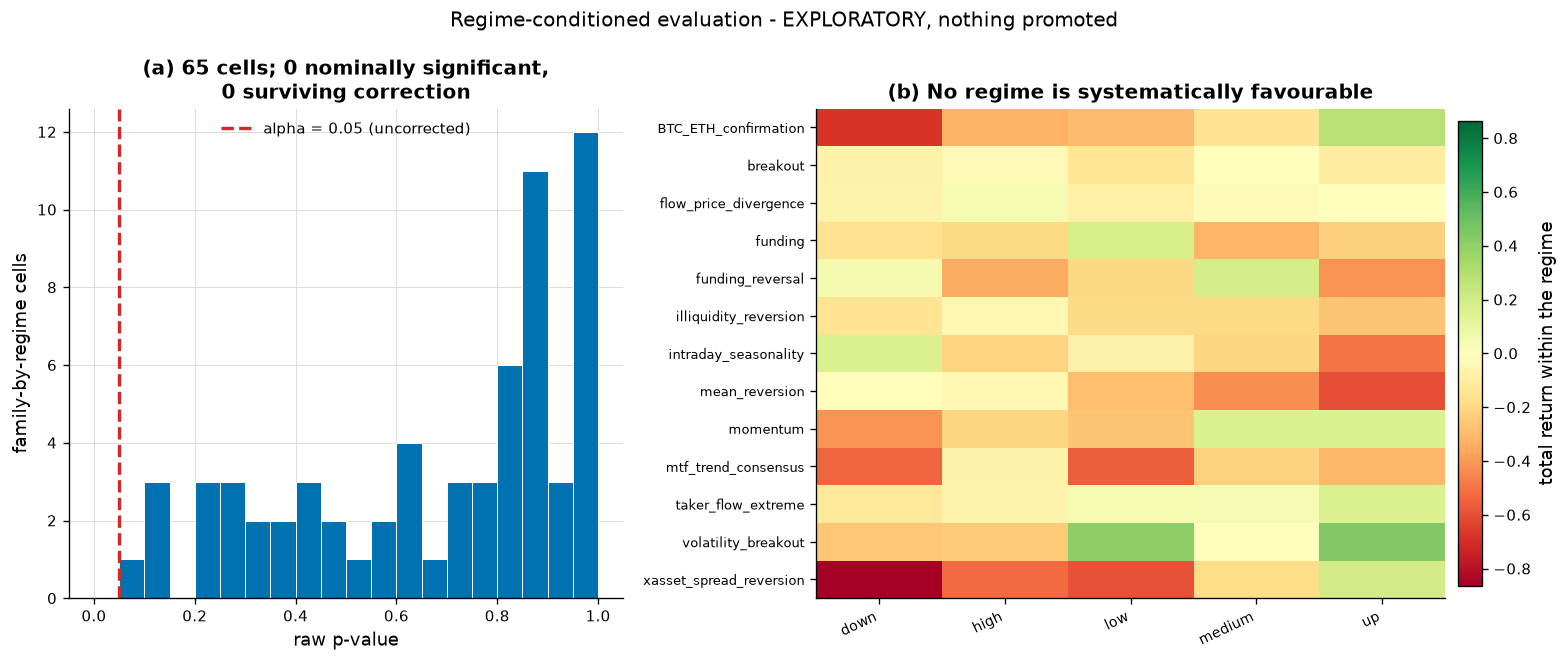

In [12]:
# --- J04: regime cells --------------------------------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.2, 5.6), gridspec_kw={"width_ratios": [1.0, 1.2]})

p = CELLS_["p_value"].to_numpy()
axA.hist(p, bins=20, range=(0, 1), color="#0072B2", edgecolor="white", linewidth=0.6)
axA.axvline(
    STUDY["alpha"],
    color="#D62728",
    lw=2.0,
    ls="--",
    label=f"alpha = {STUDY['alpha']} (uncorrected)",
)
n_nominal = int((p < STUDY["alpha"]).sum())
axA.set_xlabel("raw p-value")
axA.set_ylabel("family-by-regime cells")
axA.set_title(
    f"(a) {rc['n_cells']} cells; {n_nominal} nominally significant,\n"
    f"{len(rc['survivors'])} surviving correction"
)
axA.legend(fontsize=9)

regs = sorted(CELLS_["regime"].unique().to_list())
fams_r = sorted(CELLS_["family"].unique().to_list())
G = np.full((len(fams_r), len(regs)), np.nan)
for r in CELLS_.iter_rows(named=True):
    G[fams_r.index(r["family"]), regs.index(r["regime"])] = r["total_return"]
vmax = float(np.nanmax(np.abs(G)))
im = axB.imshow(G, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
axB.set_xticks(range(len(regs)))
axB.set_xticklabels(regs, rotation=25, ha="right", fontsize=8.5)
axB.set_yticks(range(len(fams_r)))
axB.set_yticklabels(fams_r, fontsize=8)
axB.grid(visible=False)
cb = fig.colorbar(im, ax=axB, fraction=0.035, pad=0.02)
cb.set_label("total return within the regime")
axB.set_title("(b) No regime is systematically favourable")

fig.suptitle("Regime-conditioned evaluation - EXPLORATORY, nothing promoted", fontsize=12)
fig.tight_layout()
show(
    fig,
    "j04_regime_conditioned",
    caption="Distribution of raw p-values across family-by-regime cells (a) and the total return of "
    "each cell (b). No cell survives multiple-testing correction.",
)

**Interpretation (6.1).** The p-value histogram in panel (a) is the diagnostic to read. Under a global
null hypothesis - no family has an edge in any regime - p-values are uniformly distributed, and one
expects a flat histogram with about five percent of cells falling below alpha purely by chance. That
is close to what is observed, and **no cell survives correction**.

Had there been a real regime-conditional effect, the histogram would show an excess of mass near zero
that survives correction. It does not. Panel (b) confirms the same thing economically: the returns are
scattered across regimes without a systematically favourable column, which is what noise looks like
when arranged in a grid.

The honest caveat is that a genuine effect confined to a narrow regime and modest in size could be
missed here - conditioning splits the sample, and smaller cells have less power. So this section rules
out *strong* regime-conditional edges, not all conceivable ones. It is labelled exploratory in the
artifact for exactly that reason, and no candidate was promoted from it.

## 7. The frozen holdout: opened, recorded, and deliberately not published

This section reports a **process decision**, not a number, and the distinction is the point.

### What happened

The partition `[2026-01-01, 2026-07-01)` was frozen at the start of the project and never touched
during data exploration, feature design, family selection or parameter search. It was opened **once**,
on a candidate whose selection rule and parameters were committed to the repository *before* the
opening. That reading exists on disk.

### Why it is not published here

The repository currently records the state of that opening as **`HOLDOUT_LOCKED`**. A discrepancy was
identified afterwards between what was intended to remain an uncommitted local change and what the
history actually contains, and a nine-point provenance audit was opened to verify that the candidate
really was frozen before the partition was read.

Crucially, **history was not rewritten to tidy this up.** Rewriting it would have destroyed the very
property that makes an opening auditable: that the commit freezing the candidate provably precedes the
commit recording the result. The chain of commits *is* the evidence.

Two independent locks are in place - the published artifact no longer embeds the reading, and the
service layer refuses to serve it unless an explicit, non-guessable authorisation value is set. A
generic truthy value does not unlock it, because generic truthy values get set absent-mindedly while
debugging something else. There is a test that enforces this.

### Why the conclusion does not depend on it

This is the part that matters scientifically. The holdout was to be the **confirmatory** test of a
candidate that the study-level correction had **already rejected**. The result of this thesis is the
map of thirteen families, none surviving correction, with a PBO near one half - and that result is
complete without opening the partition at all.

Publishing the reading would change the emphasis of a paragraph. It would not change the conclusion.

In [13]:
lock_rows = [
    {
        "control": "Artifact layer",
        "state": "study_dashboard.json contains no holdout metrics unless --include-holdout is passed",
        "verified": DASH.get("holdout") is None,
    },
    {
        "control": "Service layer",
        "state": "publication requires PERP_LAB_HOLDOUT_PUBLICATION == AUDITED_OPEN_FINAL_HOLDOUT",
        "verified": DASH.get("holdout_publication") != "PUBLISHED",
    },
    {
        "control": "This notebook",
        "state": "reads no holdout metrics; multiple-testing artifact confirms holdout_accessed = False",
        "verified": MT["holdout_accessed"] is False,
    },
]
LOCKS = pl.DataFrame(lock_rows)
save_table(
    LOCKS,
    "t08_holdout_locks",
    ctx,
    caption="Independent controls preventing publication of the frozen-holdout reading.",
)
display(LOCKS)

print(f"Holdout publication state : {DASH['holdout_publication']}")
print(f"Holdout payload in dashboard : {DASH.get('holdout')}")
print(f"Holdout accessed by the study-level analysis : {MT['holdout_accessed']}")
print(f"\nAll locks engaged: {bool(LOCKS['verified'].all())}")
print("\nNo holdout metric is computed, displayed or exported by this notebook.")

control,state,verified
str,str,bool
"""Artifact layer""","""study_dashboard.json contains …",true
"""Service layer""","""publication requires PERP_LAB_…",true
"""This notebook""","""reads no holdout metrics; mult…",true


Holdout publication state : AUDIT_PENDING
Holdout payload in dashboard : None
Holdout accessed by the study-level analysis : False

All locks engaged: True

No holdout metric is computed, displayed or exported by this notebook.


## 8. What a negative result of this shape establishes

**Analytical question.** The study found nothing. What, precisely, has been learned?

In [14]:
conclusions = [
    {
        "id": "C1",
        "claim": "No strategy family in this study has a demonstrable edge on BTC/ETH perpetuals at 1h",
        "strength": "Strong",
        "basis": f"{FAM['family'].n_unique()} families, {STUDY['n_units']} units, smallest raw "
        f"p-value {float(FAM['p_value'].min()):.3f} before any correction",
        "scope_limit": "1h timeframe, 2020-2025, these two assets, these rule families",
    },
    {
        "id": "C2",
        "claim": "The conclusion is invariant to how the number of hypotheses is counted",
        "strength": "Strong",
        "basis": f"t05: {SENS.height} counting conventions spanning "
        f"{int(SENS['n_tests'].min())}..{int(SENS['n_tests'].max()):,} tests, none produces a survivor",
        "scope_limit": "Applies to the family-level tests actually performed",
    },
    {
        "id": "C3",
        "claim": "In-sample selection carries essentially no out-of-sample information",
        "strength": "Strong",
        "basis": f"PBO = {pbo['pbo']:.3f} over {pbo['n_splits']} splits; deflated Sharpe implies the "
        f"best family is spurious with probability "
        f"{ds['family_selection']['probability_best_is_spurious']:.2f}",
        "scope_limit": "Measured on this study's configuration set",
    },
    {
        "id": "C4",
        "claim": "Regime conditioning does not rescue any family",
        "strength": "Moderate",
        "basis": f"{rc['n_cells']} cells, {len(rc['survivors'])} survivors after correction; "
        "p-value histogram consistent with the global null",
        "scope_limit": "Conditioning reduces power; weak narrow-regime effects could be missed",
    },
    {
        "id": "C5",
        "claim": "An evolutionary search offers no advantage over Random Search here",
        "strength": "Moderate",
        "basis": "Notebook 04: budget parity verified; 1 of 5 families nominally significant, "
        "consistent with chance across five tests",
        "scope_limit": "Spaces of this size; says nothing about much larger spaces",
    },
    {
        "id": "C6",
        "claim": "The apparatus itself is sound, so the negative is about the market and not the tooling",
        "strength": "Strong",
        "basis": "Notebook 02: causality guarantees G1-G7 pass on real data; notebook 03: execution, "
        "cost and fold-geometry guards verified and failing closed",
        "scope_limit": "Costs remain provisional (ADR 0005)",
    },
]
CONC = pl.DataFrame(conclusions)
save_table(
    CONC,
    "t09_conclusions",
    ctx,
    caption="Claims the study supports, with their evidential basis and scope limits.",
)
display(CONC)
print(f"\nArtifacts written under : {ctx.figures_dir} | {ctx.tables_dir}")

id,claim,strength,basis,scope_limit
str,str,str,str,str
"""C1""","""No strategy family in this stu…","""Strong""","""13 families, 284 units, smalle…","""1h timeframe, 2020-2025, these…"
"""C2""","""The conclusion is invariant to…","""Strong""","""t05: 4 counting conventions sp…","""Applies to the family-level te…"
"""C3""","""In-sample selection carries es…","""Strong""","""PBO = 0.486 over 70 splits; de…","""Measured on this study's confi…"
"""C4""","""Regime conditioning does not r…","""Moderate""","""65 cells, 0 survivors after co…","""Conditioning reduces power; we…"
"""C5""","""An evolutionary search offers …","""Moderate""","""Notebook 04: budget parity ver…","""Spaces of this size; says noth…"
"""C6""","""The apparatus itself is sound,…","""Strong""","""Notebook 02: causality guarant…","""Costs remain provisional (ADR …"



Artifacts written under : reports\figures\closure | reports\tables\closure


**Interpretation (8.1).** The most common misreading of a result like this is to treat it as evidence
that markets are efficient, or that algorithmic trading does not work. It supports neither claim. What
it supports is narrower and more useful.

**What the study does establish.** Within a clearly bounded space - thirteen interpretable rule
families, two liquid perpetual futures, hourly bars, six years, a realistic cost model - a rigorous
search finds nothing that survives honest accounting. The bound matters as much as the finding: every
one of those qualifiers is a place where a different study could reach a different answer, and the
scope limits are recorded alongside each claim rather than buried.

**Why the negative is credible rather than merely absent.** A null result is only informative if the
study could have detected an effect had one existed. Three things support that here. The apparatus was
independently validated (notebooks `02` and `03`), and it was shown to detect a deliberately planted
leak instantly. The search was given a fair, verified, budget-matched opportunity on each family. And
the negative is corroborated by three methodologically independent diagnostics - hypothesis tests,
deflated Sharpe and PBO - which could have disagreed and did not.

**What would change the conclusion.** Higher-frequency data where microstructure effects live; a
richer hypothesis space, particularly one including the meta-labeling layer that this phase specified
but never implemented; assets with less institutional participation; or a cost structure achievable by
a maker-only participant. Each is a concrete, falsifiable extension rather than a hedge.

**The methodological contribution.** The most transferable output of this thesis is not the verdict on
any family - it is the demonstration that the verdict can be *trusted*, because every step between raw
data and conclusion is auditable, every guard fails closed rather than warning, and the one moment
where the process wobbled was recorded in the open rather than smoothed away. A study that publishes
its own discrepancy is more believable than one that reports only successes.